In [43]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt,Command

from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [44]:
llm=ChatOpenAI(model='gpt-4o-mini')

In [45]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [46]:
def chat_node(state:ChatState):
    decision=interrupt({
        'type':'approval',
        'reason':"Model is about to answer a user question",
        'question':state['messages'][-1].content,
        'instruction':"Approve this question? Yes/No"
    })
    
    if decision['approved']=='no':
        return {'messages':[AIMessage(content="Not Approved")]}
    
    else:
        response=llm.invoke(state['messages'])
        return {'messages':[response]}

In [47]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

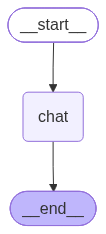

In [48]:
app

In [49]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config) #type:ignore

In [50]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='36c23e92-8dd9-4f93-b7cc-3d58bd681767')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? Yes/No'}, id='8e794304bb11b43ddea8a4533b111a62', response_schema=None)]}

In [51]:
message=result['__interrupt__'][0].value

In [52]:
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? Yes/No'}

In [53]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ").strip().lower()

In [54]:
final_result=app.invoke(
    Command(resume={'approved':user_input}),
    config=config #type:ignore
)

In [55]:
final_result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='36c23e92-8dd9-4f93-b7cc-3d58bd681767'),
  AIMessage(content='Sure! Gradient descent is a method used to find the best solution to problems, like minimizing costs in a math model. Think of it like trying to find the lowest point in a hilly landscape:\n\n1. **Imagine a Ball**: Picture a ball at some spot on a hill. Your goal is to get the ball to the lowest point (the valley).\n\n2. **Look Around**: To do this, the ball checks the ground around it to see which direction is downhill.\n\n3. **Roll Downhill**: The ball then rolls a little in that direction, finding a new spot.\n\n4. **Repeat**: It keeps checking the ground around its new position and rolls down again, repeating this process until it can’t go any lower.\n\nIn terms of math, the "hill" represents errors or costs, and the ball represents the values we\'re adjusting (like weights in a model). By c

In [56]:
print(final_result["messages"][-1].content)

Sure! Gradient descent is a method used to find the best solution to problems, like minimizing costs in a math model. Think of it like trying to find the lowest point in a hilly landscape:

1. **Imagine a Ball**: Picture a ball at some spot on a hill. Your goal is to get the ball to the lowest point (the valley).

2. **Look Around**: To do this, the ball checks the ground around it to see which direction is downhill.

3. **Roll Downhill**: The ball then rolls a little in that direction, finding a new spot.

4. **Repeat**: It keeps checking the ground around its new position and rolls down again, repeating this process until it can’t go any lower.

In terms of math, the "hill" represents errors or costs, and the ball represents the values we're adjusting (like weights in a model). By continuously tweaking these values, gradient descent helps us find the set of values that minimize errors and improve our predictions or solutions.
